In [1]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 4.1 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 4.5 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]


Gathering actor-level data across all snapshots...
[SUCCESS] Dataset creato. Totale osservazioni (attore-anno): 41829

Running Ordinary Least Squares (OLS) Regression...
                            OLS Regression Results                            
Dep. Variable:                 Degree   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     496.3
Date:                Wed, 27 May 2026   Prob (F-statistic):          6.53e-317
Time:                        10:04:59   Log-Likelihood:            -1.4999e+05
No. Observations:               41829   AIC:                         3.000e+05
Df Residuals:                   41825   BIC:                         3.000e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err        

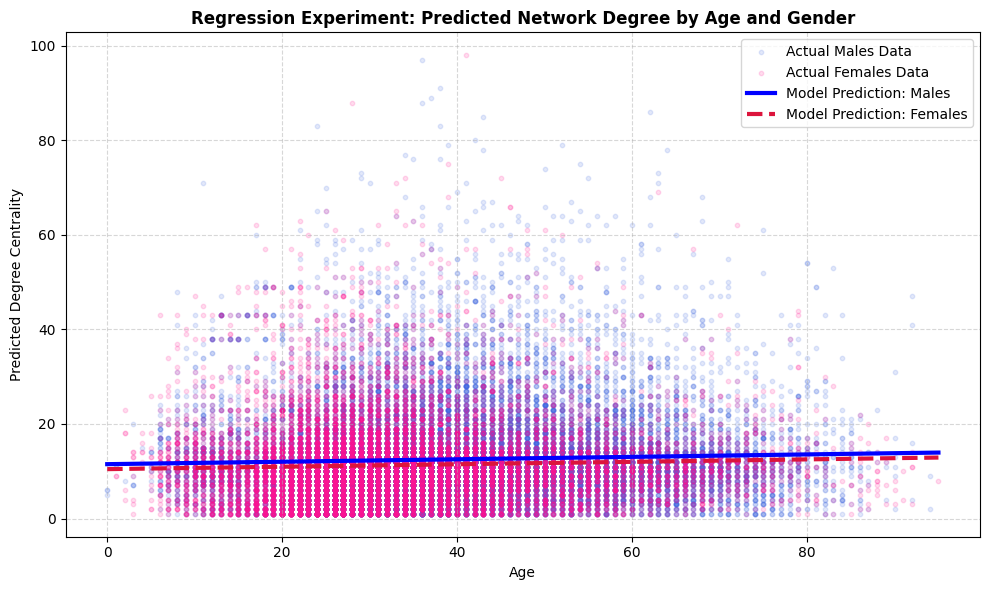

In [2]:
import os
import pickle
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. PERCORSI DEI DATI
input_dir = "data/processed/actor_projections"

all_actors_data = []

print("Gathering actor-level data across all snapshots...")

# 2. COSTRUIAMO UN UNICO DATASET CON TUTTI GLI ATTORI DI TUTTI GLI ANNI
for filename in sorted(os.listdir(input_dir)):
    if filename.endswith(".pkl") and "actors_projected_" in filename:
        year = int(filename.split("_")[2].split(".")[0])
        file_path = os.path.join(input_dir, filename)
        
        with open(file_path, 'rb') as f:
            g = pickle.load(f)
            
        # Consideriamo solo gli attori attivi in quell'anno (degree > 0)
        g_clean = g.subgraph(g.vs.select(_degree_gt=0))
        
        if g_clean.vcount() == 0:
            continue
            
        # Estraiamo le metriche di quell'anno
        genders = g_clean.vs["gender"]
        ages = [int(age) if age is not None and str(age).isdigit() else np.nan for age in g_clean.vs["age"]]
        degrees = g_clean.degree()
        betweenness = g_clean.betweenness()
        
        # Accumuliamo i dati riga per riga (ogni riga = un attore in un determinato anno)
        for i in range(g_clean.vcount()):
            if not np.isnan(ages[i]):
                all_actors_data.append({
                    "Year": year,
                    "Name": g_clean.vs[i]["name"],
                    "Gender": genders[i],
                    "Is_Female": 1 if genders[i] == "F" else 0, # Variabile dummy
                    "Age": ages[i],
                    "Degree": degrees[i],
                    "Betweenness": betweenness[i]
                })

# Convertiamo in un DataFrame Pandas
df_regression = pd.DataFrame(all_actors_data)
print(f"[SUCCESS] Dataset creato. Totale osservazioni (attore-anno): {len(df_regression)}")

# ---------------------------------------------------------------------------
# 3. L'ESPERIMENTO DI REGRESSIONE LINEARE (OLS)
# ---------------------------------------------------------------------------
# Formula: Vogliamo spiegare il Degree in base a Età, Genere Femminile e all'Anno (per controllare i trend temporali)
formula = "Degree ~ Age + Is_Female + Year"

print("\nRunning Ordinary Least Squares (OLS) Regression...")
model = smf.ols(formula=formula, data=df_regression).fit()

# Stampiamo il report completo in inglese pronto da incollare nella tesi
print(model.summary())

# ---------------------------------------------------------------------------
# 4. VISUALIZZAZIONE DEI RISULTATI DELL'ESPERIMENTO
# ---------------------------------------------------------------------------
# Creiamo un grafico che mostra l'effetto combinato di Età e Genere stimato dal modello
plt.figure(figsize=(10, 6), facecolor='white')

# Generiamo un range di età fittizio per disegnare le linee di tendenza del modello
age_range = np.linspace(df_regression["Age"].min(), df_regression["Age"].max(), 100)
mean_year = df_regression["Year"].mean()

# Calcoliamo le predizioni medie basate sui coefficienti del modello
# Formula: Intercept + (Coeff_Age * Age) + (Coeff_Female * Is_Female) + (Coeff_Year * Mean_Year)
c_intercept = model.params['Intercept']
c_age = model.params['Age']
c_female = model.params['Is_Female']
c_year = model.params['Year']

pred_males = c_intercept + (c_age * age_range) + (c_female * 0) + (c_year * mean_year)
pred_females = c_intercept + (c_age * age_range) + (c_female * 1) + (c_year * mean_year)

# Disegniamo i dati reali sotto forma di scatter leggero
plt.scatter(df_regression[df_regression["Gender"]=="M"]["Age"], df_regression[df_regression["Gender"]=="M"]["Degree"], 
            color='royalblue', alpha=0.15, s=10, label='Actual Males Data')
plt.scatter(df_regression[df_regression["Gender"]=="F"]["Age"], df_regression[df_regression["Gender"]=="F"]["Degree"], 
            color='deeppink', alpha=0.15, s=10, label='Actual Females Data')

# Disegniamo le linee di regressione stimate dal modello
plt.plot(age_range, pred_males, color='blue', linewidth=3, label='Model Prediction: Males')
plt.plot(age_range, pred_females, color='crimson', linewidth=3, linestyle='--', label='Model Prediction: Females')

plt.title("Regression Experiment: Predicted Network Degree by Age and Gender", fontsize=12, fontweight='bold')
plt.xlabel("Age", fontsize=10)
plt.ylabel("Predicted Degree Centrality", fontsize=10)
plt.legend()
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Running OLS Regression with Interaction Terms...
                            OLS Regression Results                            
Dep. Variable:                 Degree   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     372.7
Date:                Wed, 27 May 2026   Prob (F-statistic):          5.63e-316
Time:                        10:05:22   Log-Likelihood:            -1.4999e+05
No. Observations:               41829   AIC:                         3.000e+05
Df Residuals:                   41824   BIC:                         3.000e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

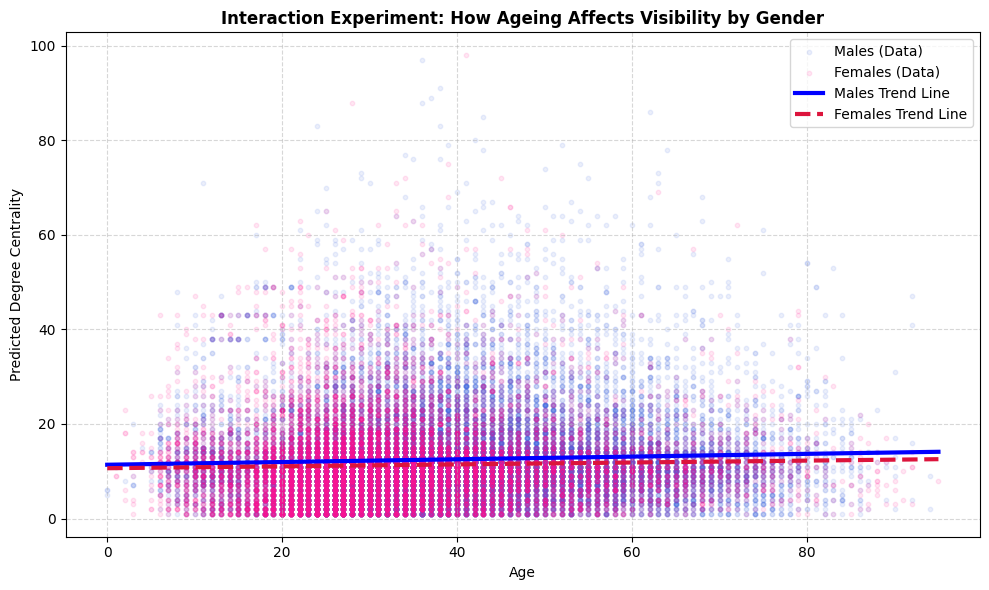

In [3]:
import os
import pickle
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. DATA GATHERING (Stessa pipeline ottimizzata)
input_dir = "data/processed/actor_projections"
all_actors_data = []

for filename in sorted(os.listdir(input_dir)):
    if filename.endswith(".pkl") and "actors_projected_" in filename:
        year = int(filename.split("_")[2].split(".")[0])
        file_path = os.path.join(input_dir, filename)
        
        with open(file_path, 'rb') as f:
            g = pickle.load(f)
            
        g_clean = g.subgraph(g.vs.select(_degree_gt=0))
        if g_clean.vcount() == 0:
            continue
            
        genders = g_clean.vs["gender"]
        ages = [int(age) if age is not None and str(age).isdigit() else np.nan for age in g_clean.vs["age"]]
        degrees = g_clean.degree()
        
        for i in range(g_clean.vcount()):
            if not np.isnan(ages[i]):
                all_actors_data.append({
                    "Year": year,
                    "Gender": genders[i],
                    "Is_Female": 1 if genders[i] == "F" else 0,
                    "Age": ages[i],
                    "Degree": degrees[i]
                })

df_regression = pd.DataFrame(all_actors_data)

# ---------------------------------------------------------------------------
# 2. REGRESSIONE CON INTERAZIONE (Age * Is_Female)
# ---------------------------------------------------------------------------
# L'asterisco calcola: Age + Is_Female + (Age : Is_Female)
formula_interaction = "Degree ~ Age * Is_Female + Year"

print("Running OLS Regression with Interaction Terms...")
model_int = smf.ols(formula=formula_interaction, data=df_regression).fit()
print(model_int.summary())

# ---------------------------------------------------------------------------
# 3. PLOT DELLE LINEE DI TENDENZA DIVERGENTI
# ---------------------------------------------------------------------------
plt.figure(figsize=(10, 6), facecolor='white')

age_range = np.linspace(df_regression["Age"].min(), df_regression["Age"].max(), 100)
mean_year = df_regression["Year"].mean()

# Estraiamo i coefficienti per calcolare le pendenze personalizzate
b_intercept = model_int.params['Intercept']
b_age = model_int.params['Age']
b_female = model_int.params['Is_Female']
b_interaction = model_int.params['Age:Is_Female']
b_year = model_int.params['Year']

# Per gli uomini (Is_Female = 0), il termine di interazione si annulla
pred_males = b_intercept + (b_age * age_range) + (b_year * mean_year)

# Per le donne (Is_Female = 1), cambiano sia l'intercetta che la pendenza dell'età!
pred_females = (b_intercept + b_female) + ((b_age + b_interaction) * age_range) + (b_year * mean_year)

# Scatter plot dei dati reali di sfondo
plt.scatter(df_regression[df_regression["Gender"]=="M"]["Age"], df_regression[df_regression["Gender"]=="M"]["Degree"], 
            color='royalblue', alpha=0.1, s=10, label='Males (Data)')
plt.scatter(df_regression[df_regression["Gender"]=="F"]["Age"], df_regression[df_regression["Gender"]=="F"]["Degree"], 
            color='deeppink', alpha=0.1, s=10, label='Females (Data)')

# Linee di regressione
plt.plot(age_range, pred_males, color='blue', linewidth=3, label='Males Trend Line')
plt.plot(age_range, pred_females, color='crimson', linewidth=3, linestyle='--', label='Females Trend Line')

plt.title("Interaction Experiment: How Ageing Affects Visibility by Gender", fontsize=12, fontweight='bold')
plt.xlabel("Age", fontsize=10)
plt.ylabel("Predicted Degree Centrality", fontsize=10)
plt.legend()
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()